In [60]:
import matplotlib.pyplot as plt
import numpy as np

from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense,Flatten
from keras.utils import to_categorical

#### CARGA DEL DATASET (MNIST)

 MNIST contiene imágenes de dígitos escritos a mano (0–9)
 - imágenes: matrices 28x28 en escala de grises
 - etiquetas: número real representado en la imagen

In [61]:
(imagenes_entrenamiento, etiquetas_entrenamiento), (imagenes_prueba, etiquetas_prueba) = mnist.load_data() #El dataset son numeros dibujados y las etiquetas son el numero que se dibuja

 #### NORMALIZACIÓN DE IMÁGENES

Convertimos los valores de píxeles de [0,255] a [0,1]<br>
Esto mejora el entrenamiento de la red neuronal

In [62]:
imagenes_entrenamiento = imagenes_entrenamiento / 255.0 # 255 porque es el valor maximo del dataset
imagenes_prueba = imagenes_prueba / 255.0

Convertimos etiquetas (ej: 5) → vector binario (ej: [0,0,0,0,0,1,0,0,0,0])

In [63]:
etiquetas_entrenamiento = to_categorical(etiquetas_entrenamiento)
etiquetas_prueba = to_categorical(etiquetas_prueba)

##### Ejemplo de etiqueta transformada

In [64]:
etiquetas_entrenamiento[0] #En este caso etiquetas_entrenamiento tenia un 5 y ahora hemos estandarizado todos los datos para que sean 0 y 1 siendo 1 la posicion del numero origen

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

#### DEFINICIÓN DEL MODELO

In [65]:
modelo = Sequential([
    Flatten(input_shape=(28,28)),  #Las imagenes del dataset son de 28x28 (784px) por lo que en esta linea lo que hacemos es comunicar el tamaño de la imagen y hacerlas unidimensionales
    Dense(128, activation = "relu"),
    Dense(10, activation = "softmax")   #Esto es para las etiquetas en este caso, van de 0-9, 10 posiciones, y el modo de activacion en binarios es mejor con softmax
])

#### COMPILACIÓN DEL MODELO

- optimizer: cómo aprende el modelo
- loss: función de error (clasificación multiclase)
- metrics: métrica de evaluación

In [66]:
modelo.compile(optimizer="adam",
               loss="categorical_crossentropy",
               metrics=["accuracy"])

#### ENTRENAMIENTO

In [67]:
modelo.fit(imagenes_entrenamiento,
           etiquetas_entrenamiento,
           epochs = 5,
           validation_data = (imagenes_prueba, etiquetas_prueba))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9244 - loss: 0.2620 - val_accuracy: 0.9556 - val_loss: 0.1509
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9664 - loss: 0.1143 - val_accuracy: 0.9690 - val_loss: 0.1055
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9758 - loss: 0.0773 - val_accuracy: 0.9731 - val_loss: 0.0878
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9821 - loss: 0.0579 - val_accuracy: 0.9757 - val_loss: 0.0796
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9868 - loss: 0.0440 - val_accuracy: 0.9764 - val_loss: 0.0763


In [68]:
predicciones = modelo.predict(imagenes_prueba)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step


### VISUALIZAR RESULTADOS

In [69]:
def ver_imagen(array_predicciones, etiqueta_real, img):
    etiqueta_real, img = etiqueta_real.argmax(), img.squeeze()
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)
    etiqueta_predicha = np.argmax(array_predicciones)
    if etiqueta_predicha == etiqueta_real:
        color = "blue"
    else:
        color = "red"
    plt.xlabel(f"Pred: {etiqueta_predicha}, Real: {etiqueta_real}", color = color)

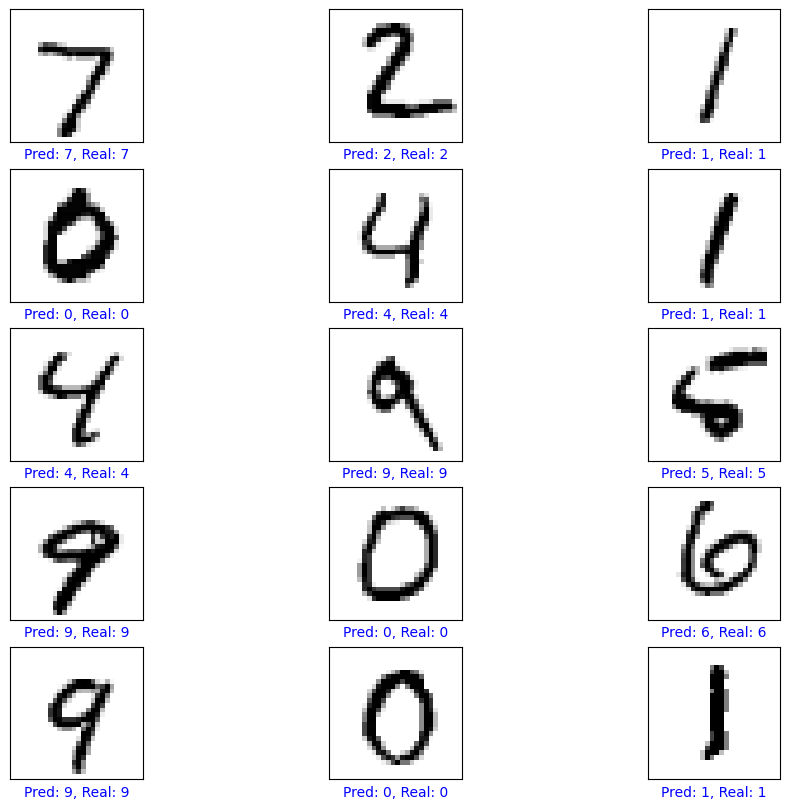

In [70]:
filas = 5
columnas = 3
n_imagenes = filas * columnas
plt.figure(figsize=(2*2*columnas, 2*filas))

for i in range(n_imagenes):
    plt.subplot(filas,2*columnas, 2*i+1)
    ver_imagen(predicciones[i], etiquetas_prueba[i], imagenes_prueba[i])